# Experimento: Impacto do encoding de SG_UF na Regressão Logística

**Motivação:** SG_UF foi codificada com `OrdinalEncoder` no modelo original, o que impõe uma ordenação arbitrária entre estados — incorreto para variável nominal em modelo linear.  
Este notebook avalia se corrigir para `OneHotEncoder` altera as métricas de forma relevante.

**O que muda:** apenas o transformer de `SG_UF` no `ColumnTransformer`.  
**O que não muda:** hiperparâmetros (C=10, L2, lbfgs), dados, threshold, random_state.  
**Nenhum modelo ou arquivo é salvo.**

In [6]:
import json
import os
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    f1_score, precision_score, confusion_matrix,
    RocCurveDisplay, PrecisionRecallDisplay,
)

BASE_DIR     = '../../data/features/baseline'
RANDOM_STATE = 42

## 1. Dados

In [7]:
X_train = pd.read_parquet(os.path.join(BASE_DIR, 'X_train.parquet'))
y_train = pd.read_parquet(os.path.join(BASE_DIR, 'y_train.parquet')).squeeze()
X_test  = pd.read_parquet(os.path.join(BASE_DIR, 'X_test.parquet'))
y_test  = pd.read_parquet(os.path.join(BASE_DIR, 'y_test.parquet')).squeeze()

with open(os.path.join(BASE_DIR, 'config.json')) as f:
    config = json.load(f)
YEAR_COL = config['split_col']

def prep_X(df):
    df = df.copy()
    if 'age_years' in df.columns:
        df.loc[df['age_years'] > 120, 'age_years'] = np.nan
    return df.drop(columns=[YEAR_COL], errors='ignore')

X_train_prep = prep_X(X_train)
X_test_prep  = prep_X(X_test)
y_train_prep = y_train.dropna()
X_train_prep = X_train_prep.loc[y_train_prep.index]
y_te = y_test.dropna()

print(f'Treino: {X_train_prep.shape} | Óbitos: {int(y_train_prep.sum()):,} ({y_train_prep.mean()*100:.2f}%)')
print(f'Teste:  {X_test_prep.shape}  | Óbitos: {int(y_te.sum()):,} ({y_te.mean()*100:.2f}%)')
print(f'\nEstados únicos em SG_UF (treino): {X_train["SG_UF"].nunique()}')

Treino: (137743, 51) | Óbitos: 2,640 (1.92%)
Teste:  (160534, 51)  | Óbitos: 5,295 (3.30%)

Estados únicos em SG_UF (treino): 27


## 2. Definição dos pipelines

Preprocessamento idêntico ao modelo original — única diferença: `SG_UF`.

In [8]:
ALRM_COLS = [c for c in X_train.columns if c.startswith('ALRM_')]
GRAV_COLS = [c for c in X_train.columns if c.startswith('GRAV_')]
SYMP_COLS = [
    'FEBRE','MIALGIA','CEFALEIA','EXANTEMA','VOMITO','NAUSEA',
    'DOR_COSTAS','CONJUNTVIT','ARTRITE','ARTRALGIA','PETEQUIA_N',
    'LEUCOPENIA','LACO','DOR_RETRO','DIABETES','HEMATOLOG',
    'HEPATOPAT','RENAL','HIPERTENSA','AUTO_IMUNE',
]
SYMP_COLS = [c for c in SYMP_COLS if c in X_train.columns]

SHARED_TRANSFORMERS = [
    ('alrm_grav', SimpleImputer(strategy='constant', fill_value=0), ALRM_COLS + GRAV_COLS),
    ('sintomas',  SimpleImputer(strategy='most_frequent'), SYMP_COLS),
    ('age',       Pipeline([('imp', SimpleImputer(strategy='median')),
                             ('scl', StandardScaler())]), ['age_years']),
    ('epi',       Pipeline([('imp', SimpleImputer(strategy='median')),
                             ('scl', StandardScaler())]), ['epi_week']),
    ('sexo',      Pipeline([('enc', OrdinalEncoder(categories=[['F','M']],
                                                    handle_unknown='use_encoded_value',
                                                    unknown_value=np.nan)),
                             ('imp', SimpleImputer(strategy='most_frequent'))]), ['CS_SEXO']),
    ('escol',     Pipeline([('imp', SimpleImputer(strategy='median')),
                             ('scl', StandardScaler())]), ['CS_ESCOL_N']),
    ('raca',      Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                             ('enc', OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))]), ['CS_RACA']),
    ('gestant',   Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                             ('enc', OneHotEncoder(handle_unknown='ignore',
                                                   sparse_output=False))]), ['CS_GESTANT']),
]

CLF_PARAMS = dict(C=10, penalty='l2', solver='lbfgs',
                  class_weight='balanced', max_iter=1000,
                  random_state=RANDOM_STATE)

def build_pipeline_ordinal():
    pre = ColumnTransformer(
        transformers=SHARED_TRANSFORMERS + [
            ('uf', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['SG_UF']),
        ],
        remainder='drop', verbose_feature_names_out=False,
    )
    return Pipeline([('pre', pre), ('clf', LogisticRegression(**CLF_PARAMS))])

def build_pipeline_onehot():
    pre = ColumnTransformer(
        transformers=SHARED_TRANSFORMERS + [
            ('uf', Pipeline([
                ('imp', SimpleImputer(strategy='most_frequent')),
                ('enc', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
            ]), ['SG_UF']),
        ],
        remainder='drop', verbose_feature_names_out=False,
    )
    return Pipeline([('pre', pre), ('clf', LogisticRegression(**CLF_PARAMS))])

print('Pipelines definidos.')

Pipelines definidos.


## 3. Treino e avaliação

In [9]:
def calcular_metricas(y_true, y_proba, label):
    y_pred = (y_proba >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        'modelo':         label,
        'sensibilidade':  round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
        'especificidade': round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
        'auprc':          round(average_precision_score(y_true, y_proba), 4),
        'roc_auc':        round(roc_auc_score(y_true, y_proba), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'precisao':       round(precision_score(y_true, y_pred, zero_division=0), 4),
    }

pipe_ordinal = build_pipeline_ordinal()
pipe_ordinal.fit(X_train_prep, y_train_prep)
proba_ordinal = pipe_ordinal.predict_proba(X_test_prep)[:, 1][y_test.notna().values]
met_ordinal = calcular_metricas(y_te, proba_ordinal, 'LR tuned — OrdinalEncoder (original)')
print(f"[OrdinalEncoder] Sensibilidade={met_ordinal['sensibilidade']} | AUPRC={met_ordinal['auprc']} | ROC-AUC={met_ordinal['roc_auc']}")

pipe_onehot = build_pipeline_onehot()
pipe_onehot.fit(X_train_prep, y_train_prep)
proba_onehot = pipe_onehot.predict_proba(X_test_prep)[:, 1][y_test.notna().values]
met_onehot = calcular_metricas(y_te, proba_onehot, 'LR tuned — OneHotEncoder (corrigido)')
print(f"[OneHotEncoder]  Sensibilidade={met_onehot['sensibilidade']} | AUPRC={met_onehot['auprc']} | ROC-AUC={met_onehot['roc_auc']}")

n_features_ordinal = pipe_ordinal['pre'].transform(X_test_prep[:1]).shape[1]
n_features_onehot  = pipe_onehot['pre'].transform(X_test_prep[:1]).shape[1]
print(f'\nFeatures — OrdinalEncoder: {n_features_ordinal} | OneHotEncoder: {n_features_onehot}')

[OrdinalEncoder] Sensibilidade=0.8008 | AUPRC=0.625 | ROC-AUC=0.9242
[OneHotEncoder]  Sensibilidade=0.8079 | AUPRC=0.6194 | ROC-AUC=0.9207

Features — OrdinalEncoder: 60 | OneHotEncoder: 86


## 4. Comparação das métricas

In [10]:
df_comp = pd.DataFrame([met_ordinal, met_onehot]).set_index('modelo')

df_diff = (df_comp.loc['LR tuned — OneHotEncoder (corrigido)'] -
           df_comp.loc['LR tuned — OrdinalEncoder (original)']).rename('Δ (OHE − Ordinal)')

df_resultado = pd.concat([df_comp, df_diff.to_frame().T])
display(df_resultado)

METRICAS = ['sensibilidade', 'especificidade', 'auprc', 'roc_auc', 'f1']
print('\nDiferença (OneHotEncoder − OrdinalEncoder):')
for m in METRICAS:
    diff = met_onehot[m] - met_ordinal[m]
    sinal = '+' if diff >= 0 else ''
    print(f'  {m:<18} {sinal}{diff:.4f}')

,sensibilidade,especificidade,auprc,roc_auc,f1,precisao
LR tuned — OrdinalEncoder (original),0.8008,0.8853,0.6250,0.9242,0.3102,0.1923
LR tuned — OneHotEncoder (corrigido),0.8079,0.8681,0.6194,0.9207,0.2848,0.1729
Δ (OHE − Ordinal),0.0071,-0.0172,-0.0056,-0.0035,-0.0254,-0.0194



Diferença (OneHotEncoder − OrdinalEncoder):
  sensibilidade      +0.0071
  especificidade     -0.0172
  auprc              -0.0056
  roc_auc            -0.0035
  f1                 -0.0254


## 5. Curvas ROC e PR

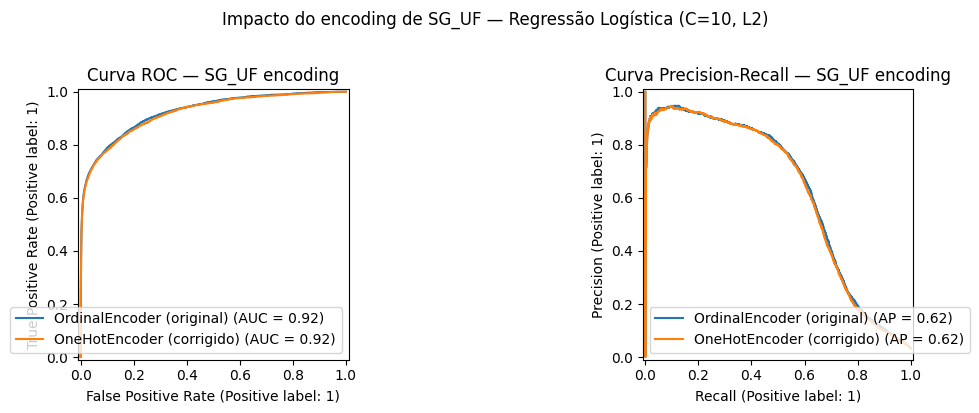

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

RocCurveDisplay.from_predictions(y_te, proba_ordinal, ax=axes[0], name='OrdinalEncoder (original)')
RocCurveDisplay.from_predictions(y_te, proba_onehot,  ax=axes[0], name='OneHotEncoder (corrigido)')
axes[0].set_title('Curva ROC — SG_UF encoding')

PrecisionRecallDisplay.from_predictions(y_te, proba_ordinal, ax=axes[1], name='OrdinalEncoder (original)')
PrecisionRecallDisplay.from_predictions(y_te, proba_onehot,  ax=axes[1], name='OneHotEncoder (corrigido)')
axes[1].set_title('Curva Precision-Recall — SG_UF encoding')

plt.suptitle('Impacto do encoding de SG_UF — Regressão Logística (C=10, L2)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Coeficientes de SG_UF — versão corrigida

Com OneHotEncoder, cada estado recebe seu próprio coeficiente.  
Permite identificar quais estados o modelo associa a maior/menor risco.

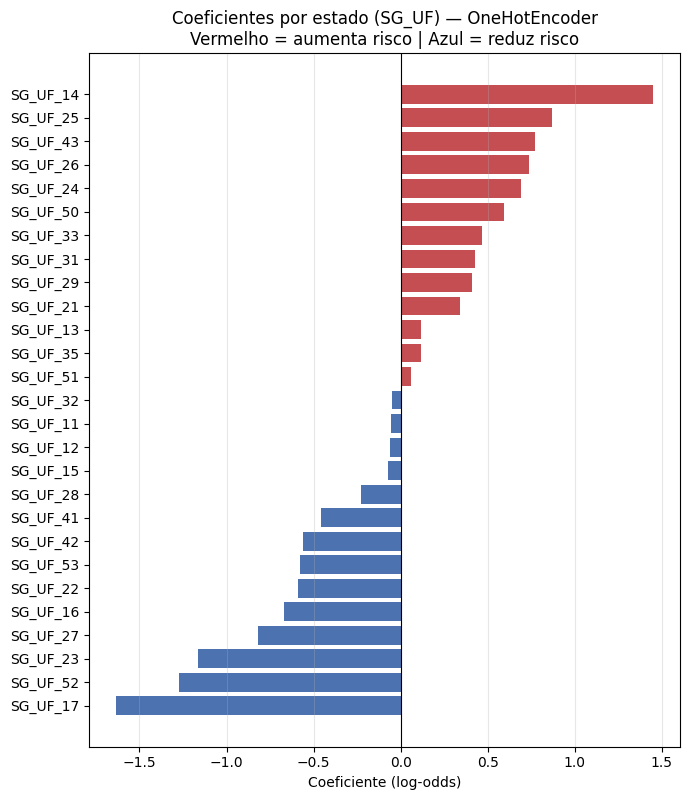


Top 5 estados com maior risco:


,feature,coeficiente
3,SG_UF_14,1.449986
11,SG_UF_25,0.867734
22,SG_UF_43,0.774223
12,SG_UF_26,0.736616
10,SG_UF_24,0.688836



Top 5 estados com menor risco:


,feature,coeficiente
6,SG_UF_17,-1.634901
25,SG_UF_52,-1.272093
9,SG_UF_23,-1.163944
13,SG_UF_27,-0.819921
5,SG_UF_16,-0.669938


In [12]:
feature_names_ohe = list(pipe_onehot['pre'].get_feature_names_out())
coefs_ohe = pipe_onehot['clf'].coef_[0]

uf_features = [(n, c) for n, c in zip(feature_names_ohe, coefs_ohe) if 'SG_UF' in n]
df_uf = pd.DataFrame(uf_features, columns=['feature', 'coeficiente']).sort_values('coeficiente')

fig, ax = plt.subplots(figsize=(7, max(4, len(df_uf) * 0.3)))
cores = ['#C44E52' if c > 0 else '#4C72B0' for c in df_uf['coeficiente']]
ax.barh(df_uf['feature'], df_uf['coeficiente'], color=cores)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Coeficientes por estado (SG_UF) — OneHotEncoder\nVermelho = aumenta risco | Azul = reduz risco')
ax.set_xlabel('Coeficiente (log-odds)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('\nTop 5 estados com maior risco:')
display(df_uf.tail(5)[['feature', 'coeficiente']].iloc[::-1])
print('\nTop 5 estados com menor risco:')
display(df_uf.head(5)[['feature', 'coeficiente']])

## 7. Conclusão

In [13]:
delta_sens = met_onehot['sensibilidade'] - met_ordinal['sensibilidade']
delta_auprc = met_onehot['auprc'] - met_ordinal['auprc']
delta_roc = met_onehot['roc_auc'] - met_ordinal['roc_auc']

LIMIAR = 0.005

if max(abs(delta_sens), abs(delta_auprc), abs(delta_roc)) < LIMIAR:
    conclusao = (
        f'O encoding de SG_UF tem impacto DESPREZÍVEL nas métricas (Δ < {LIMIAR}).\n'
        f'A remoção da feature pode ser justificada com base em seu baixo poder preditivo,\n'
        f'independentemente do encoding utilizado.'
    )
else:
    conclusao = (
        f'O encoding de SG_UF tem impacto RELEVANTE nas métricas (Δ ≥ {LIMIAR}).\n'
        f'Recomenda-se usar OneHotEncoder e reavaliar a inclusão da feature no modelo final.'
    )

print('=' * 60)
print(conclusao)
print('=' * 60)
print(f'  Δ Sensibilidade: {"+" if delta_sens >= 0 else ""}{delta_sens:.4f}')
print(f'  Δ AUPRC:         {"+" if delta_auprc >= 0 else ""}{delta_auprc:.4f}')
print(f'  Δ ROC-AUC:       {"+" if delta_roc >= 0 else ""}{delta_roc:.4f}')

O encoding de SG_UF tem impacto RELEVANTE nas métricas (Δ ≥ 0.005).
Recomenda-se usar OneHotEncoder e reavaliar a inclusão da feature no modelo final.
  Δ Sensibilidade: +0.0071
  Δ AUPRC:         -0.0056
  Δ ROC-AUC:       -0.0035


## 8. Modelo sem SG_UF

Avalia se remover completamente a feature altera as métricas em relação ao modelo original (OrdinalEncoder).

In [14]:
pre_sem_uf = ColumnTransformer(
    transformers=SHARED_TRANSFORMERS,
    remainder='drop', verbose_feature_names_out=False,
)
pipe_sem_uf = Pipeline([('pre', pre_sem_uf), ('clf', LogisticRegression(**CLF_PARAMS))])
pipe_sem_uf.fit(X_train_prep, y_train_prep)
proba_sem_uf = pipe_sem_uf.predict_proba(X_test_prep)[:, 1][y_test.notna().values]
met_sem_uf = calcular_metricas(y_te, proba_sem_uf, 'LR tuned — sem SG_UF')

ref = met_ordinal
novo = met_sem_uf

print('=' * 60)
print('Modelo sem SG_UF vs. original (OrdinalEncoder)')
print('=' * 60)
print(f"  Sensibilidade: {novo['sensibilidade']:.4f}  (Δ {novo['sensibilidade'] - ref['sensibilidade']:+.4f})")
print(f"  AUPRC:         {novo['auprc']:.4f}  (Δ {novo['auprc'] - ref['auprc']:+.4f})")
print(f"  ROC-AUC:       {novo['roc_auc']:.4f}  (Δ {novo['roc_auc'] - ref['roc_auc']:+.4f})")
print('=' * 60)

diffs = [abs(novo[m] - ref[m]) for m in ['sensibilidade', 'auprc', 'roc_auc']]
if max(diffs) < 0.005:
    print('Conclusão: remover SG_UF tem impacto DESPREZÍVEL — remoção justificada.')
else:
    print('Conclusão: remover SG_UF tem impacto RELEVANTE — feature contribui para o modelo.')

Modelo sem SG_UF vs. original (OrdinalEncoder)
  Sensibilidade: 0.8008  (Δ +0.0000)
  AUPRC:         0.6254  (Δ +0.0004)
  ROC-AUC:       0.9243  (Δ +0.0001)
Conclusão: remover SG_UF tem impacto DESPREZÍVEL — remoção justificada.
